In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/kaggle/input/student-performance-dataset/Student_Performance.csv")

In [3]:
for col in df.columns:
    print(col)

student_id
age
gender
school_type
parent_education
study_hours
attendance_percentage
internet_access
travel_time
extra_activities
study_method
math_score
science_score
english_score
overall_score
final_grade


In [4]:
# Finding Null Values
df.isnull().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [5]:
# Finding Duplicates
duplicates = df[df.duplicated()]
print(duplicates)

       student_id  age  gender school_type parent_education  study_hours  \
15000        7271   15    male     private        no formal          1.8   
15001         861   19   other      public    post graduate          0.8   
15002        5391   15  female     private              phd          1.9   
15003       13419   16   other     private         graduate          0.7   
15004        5192   19  female      public    post graduate          4.9   
...           ...  ...     ...         ...              ...          ...   
24995       12047   17  female      public              phd          1.8   
24996        1102   16  female     private          diploma          2.7   
24997        4422   19   other     private    post graduate          1.0   
24998        7858   14    male     private          diploma          1.0   
24999       11621   18   other      public        no formal          0.7   

       attendance_percentage internet_access travel_time extra_activities  \
15000     

In [6]:
# FInd duplicate student of same ID
df[df['student_id'] == 861]

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
860,861,19,other,public,post graduate,0.8,98.3,no,15-30 min,no,coaching,54.3,45.4,51.5,53.9,e
15001,861,19,other,public,post graduate,0.8,98.3,no,15-30 min,no,coaching,54.3,45.4,51.5,53.9,e


In [7]:
print(df.duplicated().sum())
print(df.shape)

10000
(25000, 16)


In [8]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [9]:
print(df.duplicated().sum())
print(df.shape)

0
(15000, 16)


In [10]:
# Rename Columns
df.rename(columns={
    'math_score':'Math',
    'english_score':'English',
    'science_score':'Science'
},inplace=True)

In [11]:
df.columns

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'Math', 'Science',
       'English', 'overall_score', 'final_grade'],
      dtype='object')

In [12]:
# Create New columns Average Score and calculate score in this
df['Average_Score']=(df['Math']+df['English']+df['Science'])/3

In [13]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,Math,Science,English,overall_score,final_grade,Average_Score
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e,51.700000
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d,63.733333
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b,86.333333
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e,42.200000
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f,23.866667


In [14]:
# Create function of performance for apply conditions in Average Score column
def performance(score):
    if score >= 90:
        return "Excellent"
    elif score >= 80:
        return "Good"
    elif score >= 70:
        return "Average"
    else:
        return "Needs Improvement"

In [15]:
df['Performance']=df['Average_Score'].apply(performance)

In [78]:
df.head(10)

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,Math,Science,English,overall_score,final_grade,Average_Score,Performance
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e,51.700000,Needs Improvement
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d,63.733333,Needs Improvement
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b,86.333333,Good
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e,42.200000,Needs Improvement
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f,23.866667,Needs Improvement
5,6,19,male,public,no formal,3.8,69.6,yes,>60 min,yes,coaching,51.5,78.3,63.9,63.5,d,64.566667,Needs Improvement
6,7,14,female,private,post graduate,1.8,81.6,yes,30-60 min,no,textbook,41.9,29.4,39.2,39.1,f,36.833333,Needs Improvement
7,8,18,female,private,post graduate,5.6,59.4,yes,>60 min,yes,group study,56.7,60.1,53.4,69.6,d,56.733333,Needs Improvement
8,9,15,other,private,high school,3.2,89.6,yes,15-30 min,yes,mixed,54.1,59.5,38.3,55.2,d,50.633333,Needs Improvement
9,10,14,female,public,diploma,6.8,62.4,yes,>60 min,no,mixed,71.9,70.4,81.3,69.6,d,74.533333,Average


In [33]:
#Project
totalStudents=df.shape[0]
print('Total number of students are: ', totalStudents)

Total number of students are:  15000


In [34]:
Math=df["Math"].mean()
English=df["English"].mean()
Science=df["Science"].mean()

print('Average Score of Math: ',Math)
print('Average Score of English: ',English)
print('Average Score of Science: ',Science)

Average Score of Math:  63.77455333333334
Average Score of English:  63.70922666666666
Average Score of Science:  63.75122666666667


In [60]:
#Top 5
top5=df.nlargest(5,'Average_Score')
top5

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,Math,Science,English,overall_score,final_grade,Average_Score,Performance
23,24,19,female,public,phd,7.8,72.8,yes,15-30 min,yes,notes,100.0,100.0,100.0,94.6,b,100.0,Excellent
379,380,15,female,public,post graduate,7.0,100.0,yes,<15 min,no,mixed,100.0,100.0,100.0,100.0,a,100.0,Excellent
436,437,17,other,private,post graduate,7.8,83.4,yes,30-60 min,no,online videos,100.0,100.0,100.0,100.0,a,100.0,Excellent
493,494,17,female,private,diploma,7.9,97.3,no,>60 min,no,textbook,100.0,100.0,100.0,98.2,a,100.0,Excellent
1657,1658,19,other,private,no formal,6.8,84.1,yes,<15 min,no,coaching,100.0,100.0,100.0,95.4,a,100.0,Excellent


In [47]:
# Print who need improvements
improveStudents=df[df['Performance'] == "Needs Improvement"]
improveStudents

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,Math,Science,English,overall_score,final_grade,Average_Score,Performance
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e,51.700000,Needs Improvement
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d,63.733333,Needs Improvement
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e,42.200000,Needs Improvement
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f,23.866667,Needs Improvement
5,6,19,male,public,no formal,3.8,69.6,yes,>60 min,yes,coaching,51.5,78.3,63.9,63.5,d,64.566667,Needs Improvement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,14995,18,other,private,phd,5.8,74.0,yes,15-30 min,no,online videos,55.7,69.2,83.5,68.6,d,69.466667,Needs Improvement
14995,14996,17,male,private,graduate,1.8,53.2,yes,15-30 min,no,group study,37.1,37.1,26.8,38.4,f,33.666667,Needs Improvement
14997,14998,17,male,private,phd,5.2,58.2,yes,30-60 min,no,group study,69.0,57.2,74.1,64.3,d,66.766667,Needs Improvement
14998,14999,16,other,private,graduate,1.0,68.7,yes,30-60 min,yes,textbook,24.2,41.4,30.5,33.6,f,32.033333,Needs Improvement


In [49]:
# Print highest Class Average
math_avg = df['Math'].mean()
science_avg = df['Science'].mean()
english_avg = df['English'].mean()

subject_avg = {
    "Math": math_avg,
    "Science": science_avg,
    "English": english_avg
}

max_subject = max(subject_avg, key=subject_avg.get)

print("Highest Subject:", max_subject)
print("Max Average:", subject_avg[max_subject]

Highest Subject: Math
Max Average: 63.77455333333334


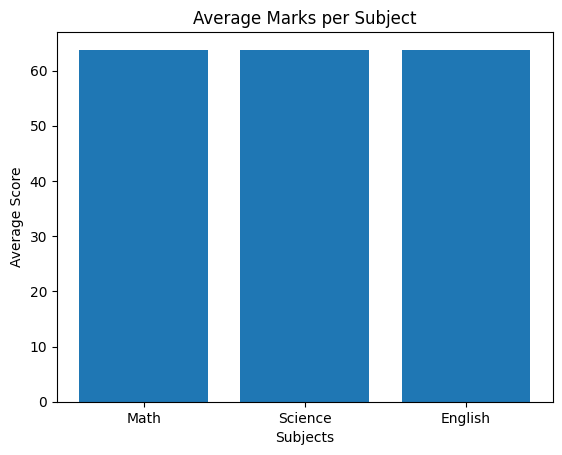

In [58]:
# Bar chart of average Marks
subjects = ['Math', 'Science', 'English']
averages = [math_avg, science_avg, english_avg]


plt.bar(subjects, averages)

plt.title("Average Marks per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.show()

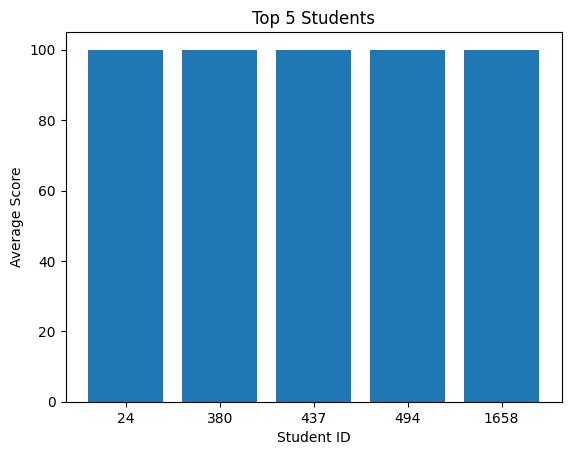

In [75]:
# Bar chart of Top-5 students

plt.bar(top5['student_id'].astype(str), top5['Average_Score'])
plt.title("Top 5 Students")
plt.xlabel("Student ID")
plt.ylabel("Average Score")
plt.show()

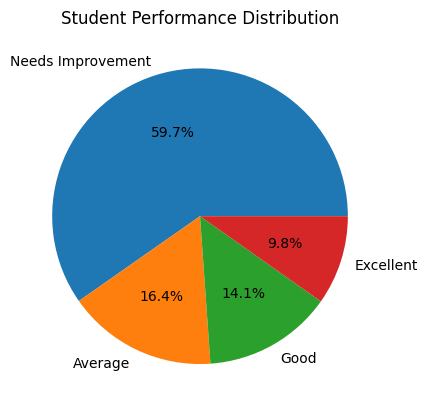

In [76]:
# Pie chart of according to their performance
performance_count = df['Performance'].value_counts()

plt.pie(performance_count,
        labels=performance_count.index,
        autopct='%1.1f%%')

plt.title("Student Performance Distribution")
plt.show()

/tmp/ipykernel_100/445842799.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['Math'], df['Science'], df['English']],


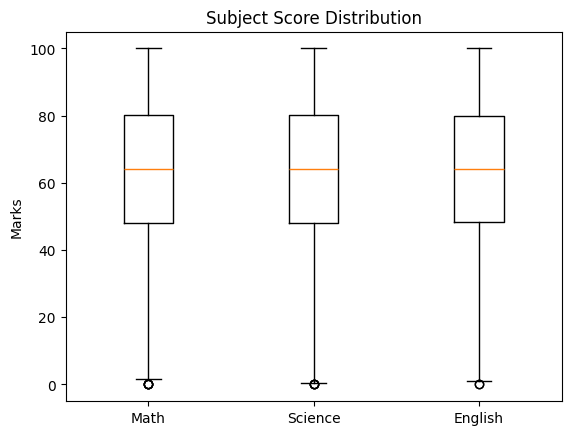

In [77]:
# Box plot of Marks to detect the outliers
plt.boxplot([df['Math'], df['Science'], df['English']],
            labels=['Math','Science','English'])

plt.title("Subject Score Distribution")
plt.ylabel("Marks")
plt.show()